In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
nav_df=pd.read_csv(r"D:\Bluestock\Project\Data\Processed\clean_nav_history.csv")

In [4]:
nav_df.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [5]:
nav_df["date"]=pd.to_datetime(nav_df["date"])

### NAV Trend Analysis (2022–2026)
This chart visualizes the daily NAV movement of all mutual fund schemes from 2022 to 2026, highlighting overall performance trends and the impact of key market events such as the COVID recovery, 2023 rally, and 2024 market correction

In [54]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig.add_vline(
    x="2022-03-01",
    line_dash="dash",
    line_color="green",
    annotation_text="COVID Recovery",
    annotation_position="top left"
)

fig.add_vline(
    x="2023-06-01",
    line_dash="dash",
    line_color="blue",
    annotation_text="2023 Rally",
    annotation_position="top left"
)

fig.add_vline(
    x="2024-09-01",
    line_dash="dash",
    line_color="red",
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_traces(
    line=dict(width=2),
    hovertemplate="<b>AMFI Code:</b> %{fullData.name}<br><b>Date:</b> %{x|%d %b %Y}<br><b>NAV:</b> ₹%{y:.2f}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    width=1300,
    height=700,
    title_x=0.5,
    hovermode="x unified",
    legend_title="AMFI Code",
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig.show()

### AUM Growth by Fund House (2022–2025)
This grouped bar chart compares the Assets Under Management (AUM) of major mutual fund houses from 2022 to 2025, highlighting year-over-year growth and market leadership

In [7]:
aum_df=pd.read_csv(r"D:\Bluestock\Project\Data\Raw\03_aum_by_fund_house.csv")

In [8]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

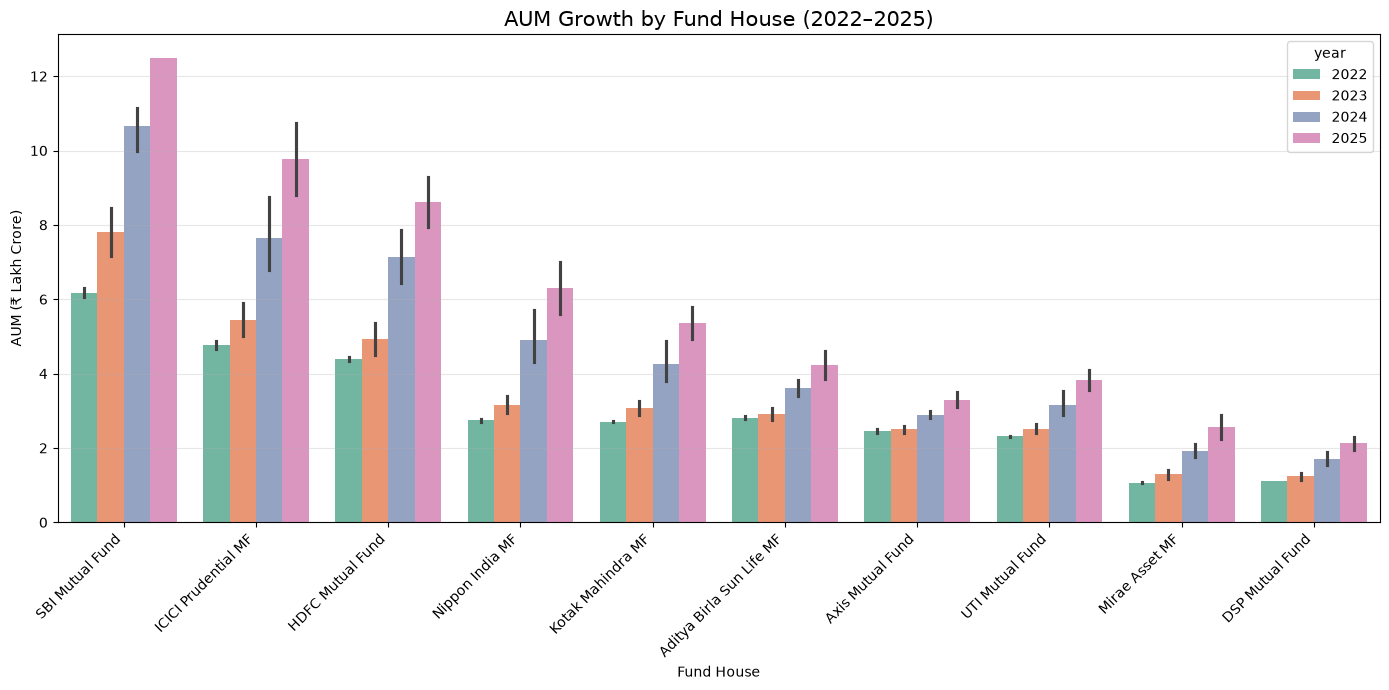

In [12]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_df,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    palette="Set2"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=15)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



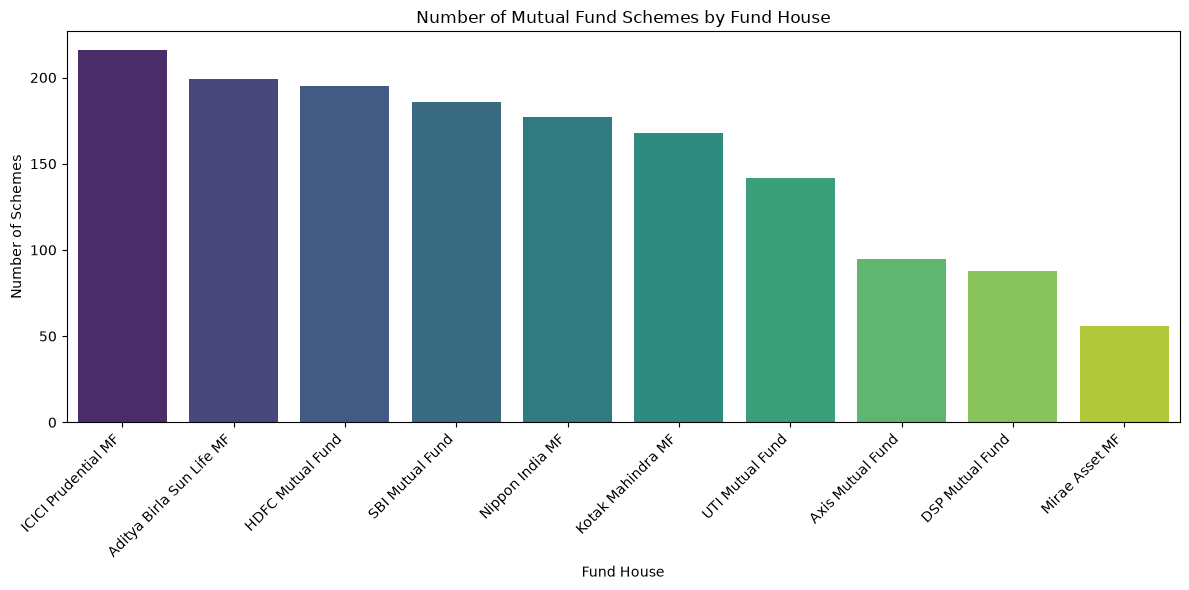

In [59]:
plt.figure(figsize=(12,6))

scheme_df = aum_df.sort_values("num_schemes", ascending=False)

sns.barplot(
    data=scheme_df,
    x="fund_house",
    y="num_schemes",
    hue="fund_house",
    palette="viridis",
    legend=False
)

plt.title("Number of Mutual Fund Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)
This line chart illustrates the monthly SIP inflows from January 2022 to December 2025, highlighting the steady growth in systematic investments and the record milestone achieved in December 2025

In [14]:
sip_df=pd.read_csv(r"D:\Bluestock\Project\Data\Raw\04_monthly_sip_inflows.csv")
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [ ]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

fig.update_traces(
    mode="lines+markers",
    line=dict(width=3),
    marker=dict(size=7),
    hovertemplate="<b>%{x|%b %Y}</b><br>SIP Inflow: ₹%{y:,} Cr<extra></extra>"
)

dec_2025 = sip_df[sip_df["month"] == "2025-12-01"]

if not dec_2025.empty:
    x = dec_2025["month"].iloc[0]
    y = dec_2025["sip_inflow_crore"].iloc[0]

    fig.add_scatter(
        x=[x],
        y=[y],
        mode="markers+text",
        marker=dict(size=14, color="red"),
        text=[f"₹{y:,} Cr"],
        textposition="top center",
        showlegend=False
    )

    fig.add_hline(
        y=y,
        line_dash="dash",
        line_color="green",
        annotation_text=f"Milestone: ₹{y:,} Cr",
        annotation_position="top left"
    )

fig.update_xaxes(
    dtick="M3",
    tickformat="%b\n%Y"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600,
    hovermode="x unified",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()


### Category-wise Net Inflow Heatmap
This heatmap illustrates the monthly net inflows across different mutual fund categories, where darker color intensity represents higher net inflows and lighter shades indicate lower inflows

In [22]:
catflow_df=pd.read_csv(r"D:\Bluestock\Project\Data\Raw\05_category_inflows.csv")
catflow_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


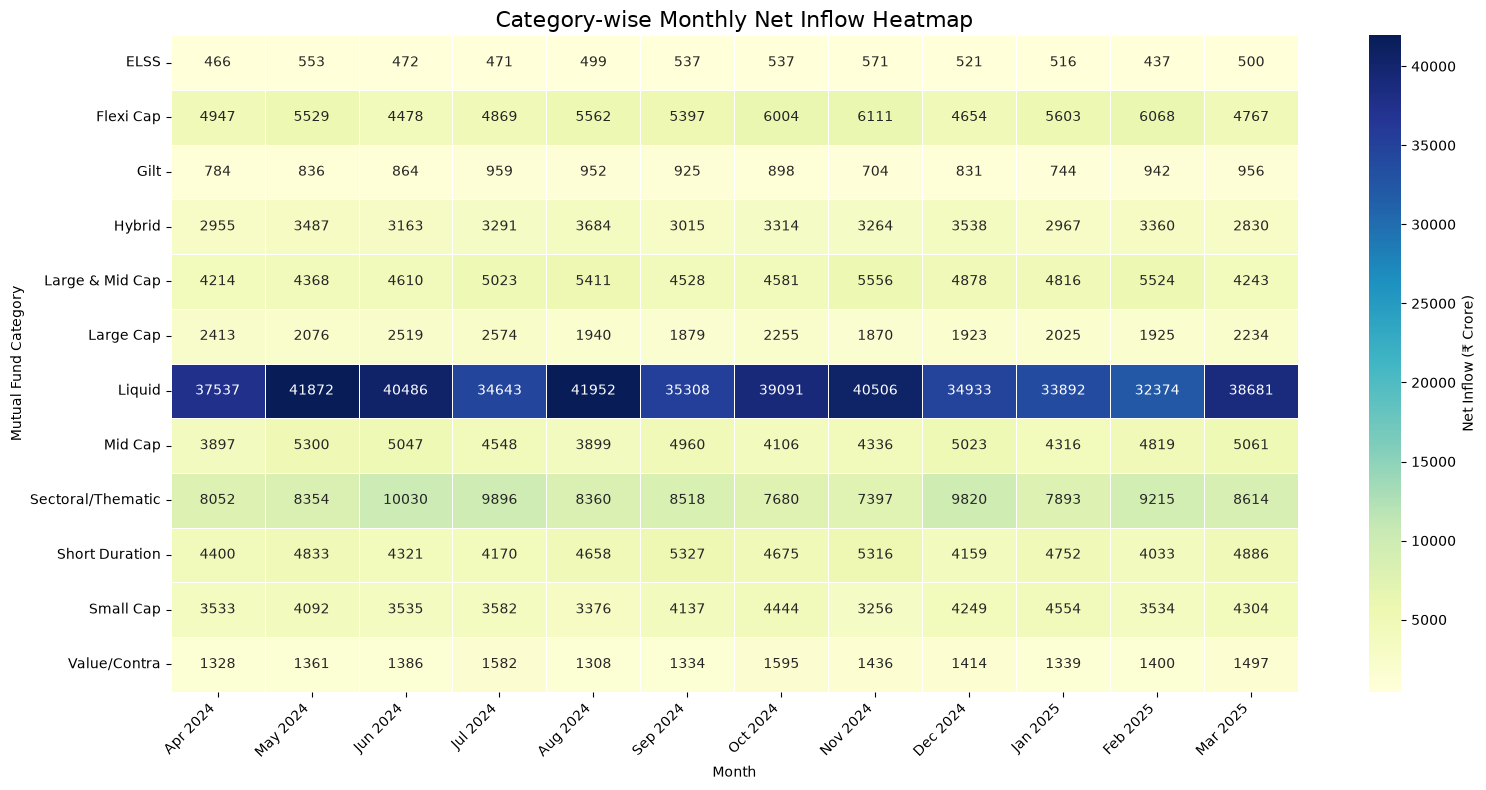

In [26]:
catflow_df["month"] = pd.to_datetime(catflow_df["month"])

heatmap_df = catflow_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_df.columns = heatmap_df.columns.strftime("%b %Y")

plt.figure(figsize=(16, 8))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title("Category-wise Monthly Net Inflow Heatmap", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Mutual Fund Category")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Investor Age Group Distribution and SIP Investment Amount by Age Group
This pie chart illustrates the distribution of investors across different age groups, providing insights into the demographic composition of mutual fund investors
This box plot compares the distribution of investment amounts across different age groups, highlighting variations in investment behavior and the presence of outliers

In [28]:
investor_df=pd.read_csv(r"D:\Bluestock\Project\Data\Raw\08_investor_transactions.csv")
investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


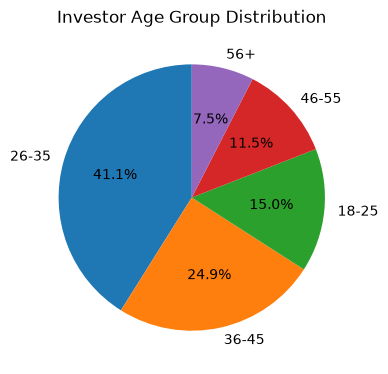

In [40]:
age_counts = investor_df["age_group"].value_counts()

plt.figure(figsize=(4, 4))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()
plt.show()

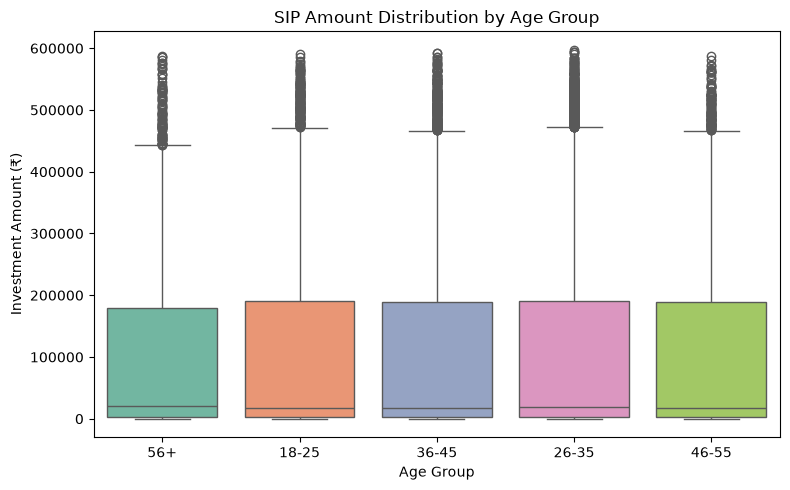

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=investor_df,
    x="age_group",
    y="amount_inr",
    hue="age_group",
    palette="Set2",
    legend=False
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()
plt.show()

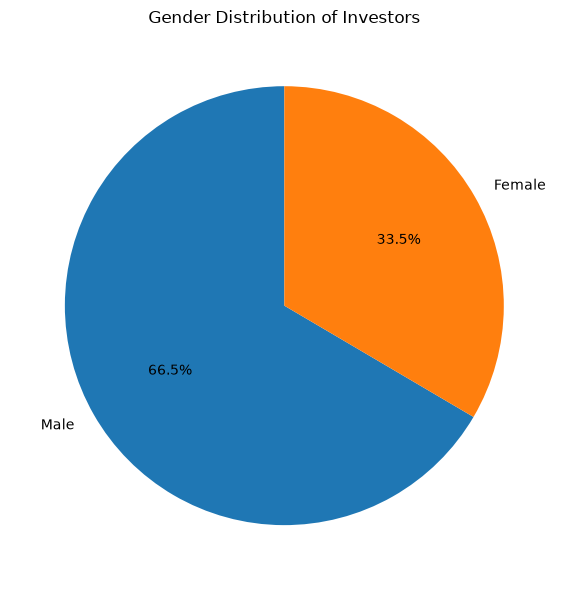

In [55]:
gender_counts = investor_df["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.tight_layout()
plt.show()

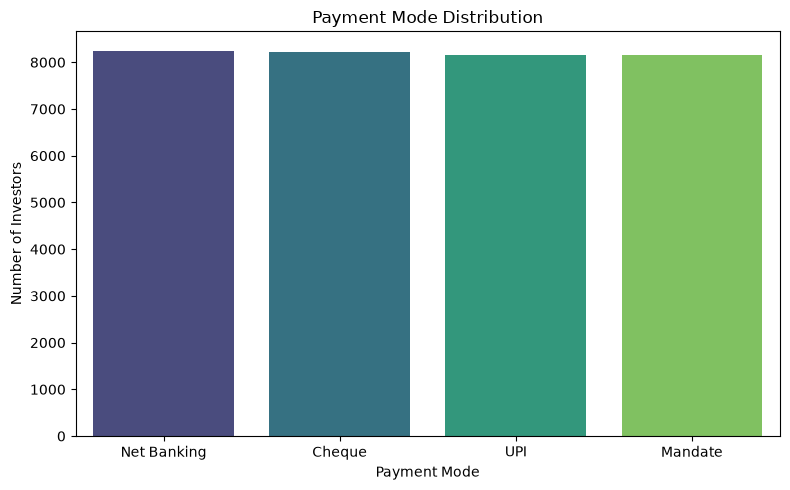

In [56]:
payment = investor_df["payment_mode"].value_counts().reset_index()
payment.columns = ["payment_mode","count"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=payment,
    x="payment_mode",
    y="count",
    hue="payment_mode",
    palette="viridis",
    legend=False
)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Investors")

plt.tight_layout()
plt.show()

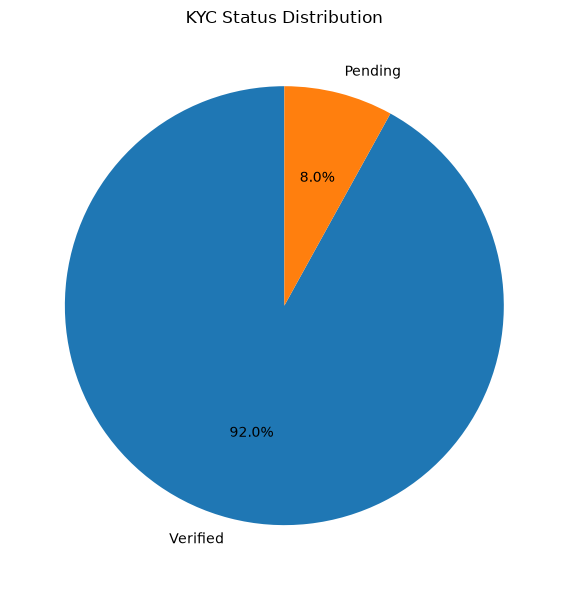

In [57]:
kyc = investor_df["kyc_status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    kyc,
    labels=kyc.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("KYC Status Distribution")

plt.tight_layout()
plt.show()

### Geographic Distribution of SIP Investments by State
This horizontal bar chart compares the total SIP investment amount across different states, highlighting regions with the highest investor participation.

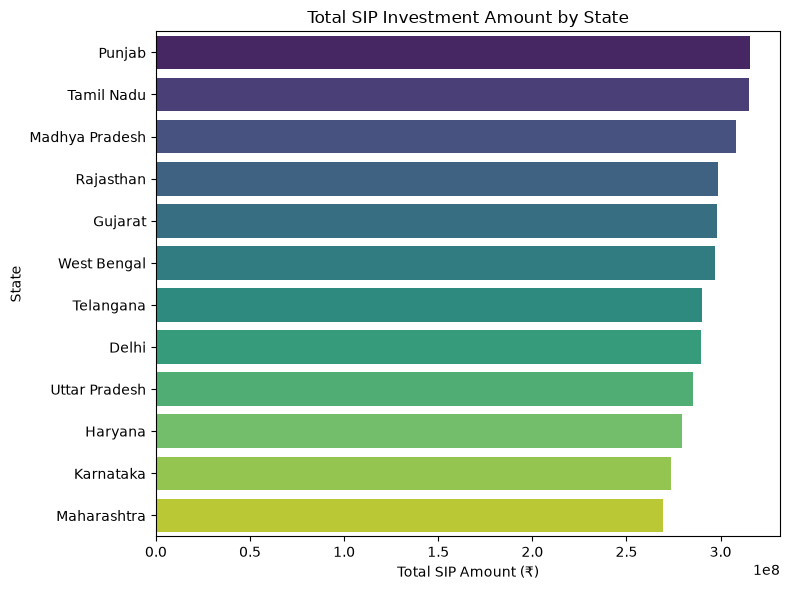

In [44]:
state_df = (
    investor_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=state_df,
    x="amount_inr",
    y="state",
    hue="state",
    palette="viridis",
    legend=False
)

plt.title("Total SIP Investment Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Folio Count Growth (Jan 2022 – Dec 2025)
This line chart illustrates the growth in total mutual fund folios from January 2022 to December 2025, highlighting the steady increase in investor participation over the analysis period.

In [45]:
folio_df=pd.read_csv(r"D:\Bluestock\Project\Data\Raw\06_industry_folio_count.csv")
folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [46]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Growth (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

fig.update_traces(
    mode="lines+markers",
    line=dict(width=3),
    marker=dict(size=8),
    hovertemplate="<b>%{x|%b %Y}</b><br>Folios: %{y:.2f} Cr<extra></extra>"
)

start = folio_df.iloc[0]
end = folio_df.iloc[-1]

fig.add_scatter(
    x=[start["month"], end["month"]],
    y=[start["total_folios_crore"], end["total_folios_crore"]],
    mode="markers+text",
    marker=dict(size=14, color="red"),
    text=[
        f'{start["total_folios_crore"]:.2f} Cr',
        f'{end["total_folios_crore"]:.2f} Cr'
    ],
    textposition="top center",
    showlegend=False
)

fig.update_xaxes(
    tickformat="%b\n%Y"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600,
    hovermode="x unified",
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

In [60]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

plot_df = folio_df.melt(
    id_vars="month",
    value_vars=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore"
    ],
    var_name="Category",
    value_name="Folios"
)

plot_df["Category"] = plot_df["Category"].str.replace("_folios_crore", "").str.title()

fig = px.line(
    plot_df,
    x="month",
    y="Folios",
    color="Category",
    markers=True,
    title="Category-wise Folio Growth (2022–2025)"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=600,
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Folios (Crore)"
)

fig.show()

### NAV Return Correlation Matrix
This heatmap shows the pairwise correlation of daily NAV returns across 10 selected mutual fund schemes, helping identify funds that exhibit similar or divergent performance patterns.

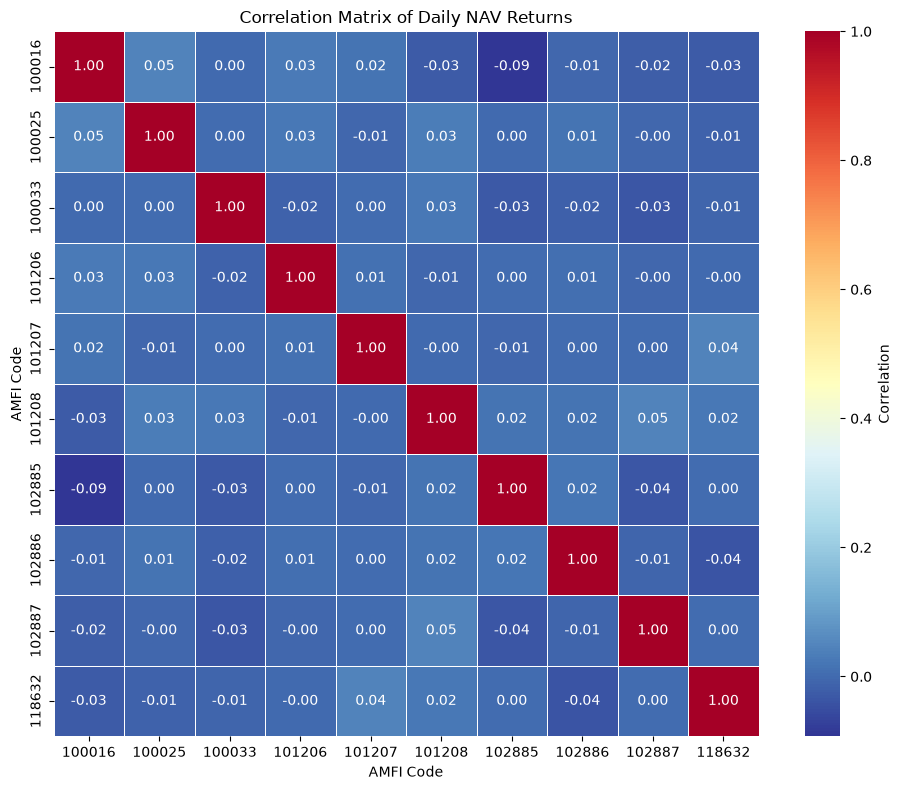

In [47]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

selected_funds = nav_df["amfi_code"].unique()[:10]

nav_subset = nav_df[nav_df["amfi_code"].isin(selected_funds)]

pivot_df = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = pivot_df.pct_change()

corr_matrix = daily_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label":"Correlation"}
)

plt.title("Correlation Matrix of Daily NAV Returns")
plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.tight_layout()
plt.show()

### Sector-wise Portfolio Allocation
This donut chart illustrates the allocation of portfolio weights across different sectors, providing an overview of sector diversification in the selected mutual fund portfolios.

In [49]:
portfolio_df=pd.read_csv(r"D:\Bluestock\Project\Data\Raw\09_portfolio_holdings.csv")
portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


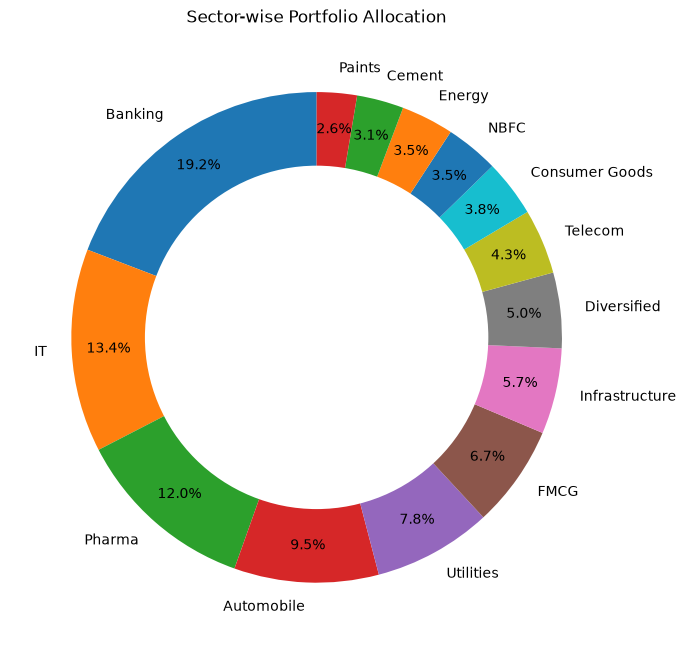

In [53]:
import matplotlib.pyplot as plt

sector_df = (
    portfolio_df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 7))

plt.pie(
    sector_df,
    labels=sector_df.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector-wise Portfolio Allocation")

plt.tight_layout()
plt.show()

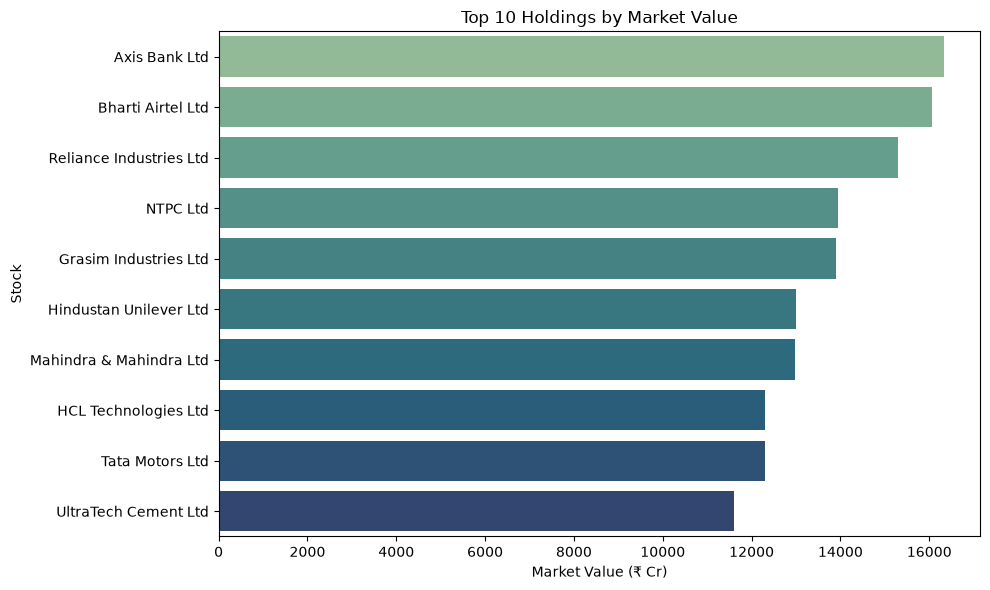

In [58]:
top10 = (
    portfolio_df.groupby("stock_name")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="market_value_cr",
    y="stock_name",
    hue="stock_name",
    palette="crest",
    legend=False
)

plt.title("Top 10 Holdings by Market Value")
plt.xlabel("Market Value (₹ Cr)")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

# Key EDA Findings

1. Daily NAVs of the selected mutual fund schemes showed an overall upward trend between 2022 and 2025, with temporary fluctuations during major market events.

2. SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), demonstrating strong market leadership throughout the analysis period.

3. Monthly SIP inflows increased steadily from January 2022 to December 2025, reaching their highest level by the end of the study period.

4. Equity-oriented categories such as Flexi Cap, Mid Cap, and Large & Mid Cap attracted the highest net inflows, indicating strong investor preference for equity investments.

5. The majority of investors belonged to the middle-age groups, highlighting that working professionals form the largest segment of mutual fund investors.

6. Older age groups generally invested larger SIP amounts and exhibited greater variation in investment values compared to younger investors.

7. SIP investments were concentrated in a few major states, while Top 30 (T30) cities accounted for a larger share of investments than Beyond Top 30 (B30) cities.

8. Total mutual fund folios grew significantly from **13.26 crore** in January 2022 to **26.12 crore** in December 2025, reflecting continuous expansion of the investor base.

9. The correlation matrix showed that most selected mutual funds exhibited positive correlations in daily NAV returns, suggesting similar responses to overall market movements.

10. Portfolio holdings were diversified across multiple sectors, with Banking, Utilities, Pharma, and other major industries contributing significantly to overall portfolio allocation.